matches:66/500


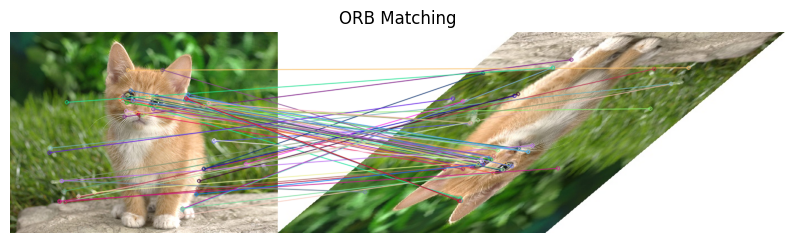

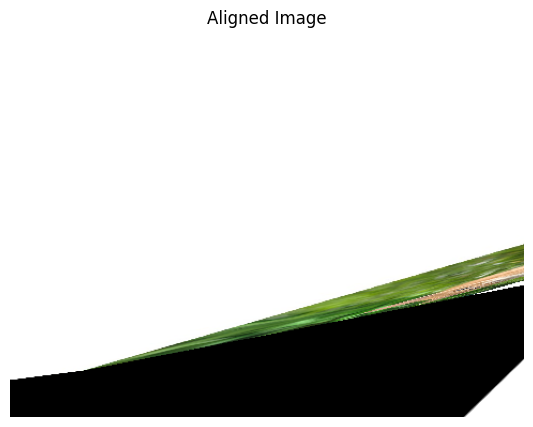

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

MAX_FEATURES = 500

template_image = cv2.imread("images/cat.jpg")
misaligned_image = cv2.imread("images/cat_a.jpg")

grey_template = cv2.cvtColor(template_image, cv2.COLOR_BGR2GRAY)
grey_misaligned = cv2.cvtColor(misaligned_image, cv2.COLOR_BGR2GRAY)

detector = cv2.ORB_create()
kp1, desc1 = detector.detectAndCompute(grey_template, None)
kp2, desc2 = detector.detectAndCompute(grey_misaligned, None)

matcher = cv2.BFMatcher(cv2.NORM_HAMMING2)  # BF-Hamming
matches = matcher.knnMatch(desc1, desc2, 2)  # knnMatch, k=2

ratio = 0.9 # Extract only those where the first neighbor's street is within 75% of the second neighbor's street.
good_matches = [
    first for first, second in matches if first.distance < second.distance * ratio
]
print("matches:%d/%d" % (len(good_matches), len(matches)))


res = cv2.drawMatches(
    template_image,
    kp1,
    misaligned_image,
    kp2,
    good_matches,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.title("ORB Matching")
plt.axis("off")
plt.show()

# Extract location of good matches
points1 = np.zeros((len(good_matches), 2), dtype=np.float32)
points2 = np.zeros((len(good_matches), 2), dtype=np.float32)

for i, match in enumerate(good_matches):
    points1[i, :] = kp1[match.queryIdx].pt
    points2[i, :] = kp2[match.trainIdx].pt

# Find homography
(h, status) = cv2.findHomography(points1, points2, cv2.RANSAC)

# Use homography
height, width, channels = template_image.shape
aligned_image = cv2.warpPerspective(misaligned_image, h, (width, height))

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
plt.title("Aligned Image")
plt.axis("off")
plt.show()

469


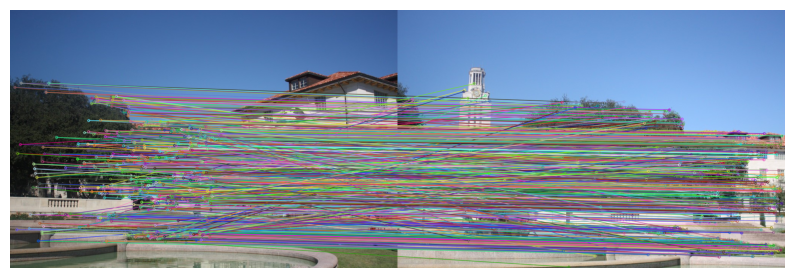

[[ 7.63138494e-01  3.82477503e-02  4.46715821e+02]
 [-1.36569965e-01  9.12083236e-01  7.62578699e+01]
 [-2.13482598e-04 -3.12847564e-05  1.00000000e+00]]


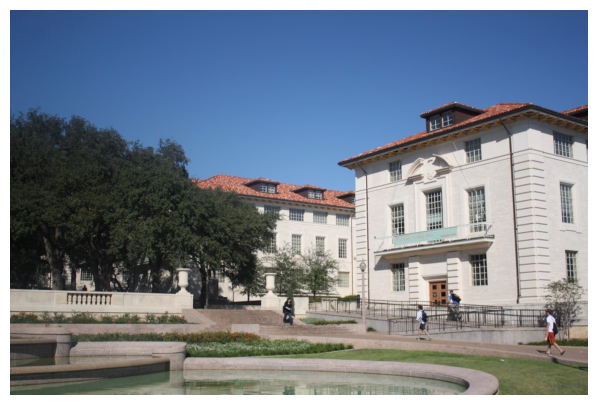

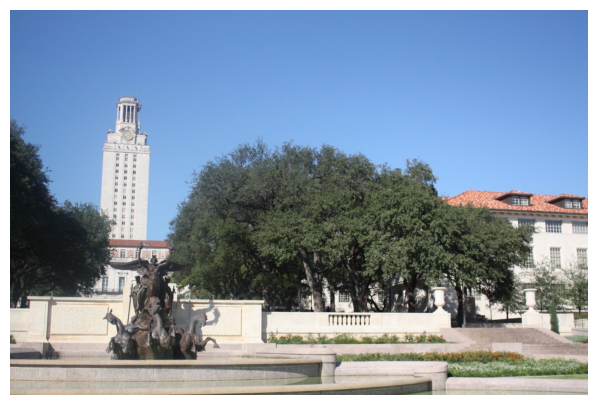

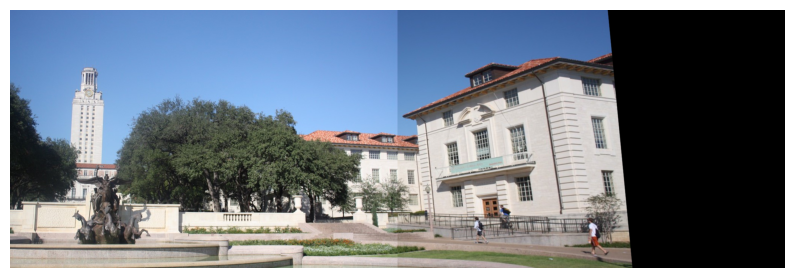

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


img1 = cv2.imread("images/foto1A.jpg")
img2 = cv2.imread("images/foto1B.jpg")
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)
good = []
ratio = 0.4
for m in matches:
    if m[0].distance < ratio * m[1].distance:
        good.append(m)

# good = sorted(good, key=lambda x: x.distance, reverse=True)
# good = good[:200]

print(len(good))

img3 = cv2.drawMatchesKnn(
    img1, kp1, img2, kp2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

kp1 = np.float32([kp.pt for kp in kp1])
kp2 = np.float32([kp.pt for kp in kp2])
pts1 = np.float32([kp1[m[0].queryIdx] for m in matches])
pts2 = np.float32([kp2[m[0].trainIdx] for m in matches])

# estimate the homography between the sets of points
(H, status) = cv2.findHomography(pts1, pts2, cv2.RANSAC)
print(H)

h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]
result = cv2.warpPerspective(img1, H, (w1 + w2, h1))
result[0:h2, 0:w2] = img2

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()